# **Error Analysis - Video Games**


# 0. Setup

Note: the predictions get retourned as BPR loss. As consequence, the predictions are not in the range of 0 to 1. To interpret them further, we need to convert them to the range of 0 to 1. Use sigmoid function.

Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import itertools
from collections import defaultdict

import sys
sys.path.append("../..")

from models.KGIL.utils.metrics import (
    levenshtein_distance,
    calc_cosine_similarity_fixed, 
    gini_coefficient
)

from utils.data_processing import Visualize_KG, Process_KG

## **2. Video Games**

### **2.1 LLM-COL-HIERARCHY-TAX (gemma3) without redundancies**

In [34]:
DATASET = "amazon-Video_Games"
EXPERIMENT_NAME = "#2 Taxonomy without redundancies"
MODEL_TECHNIQUE_NAME = "gemma3"

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

REDUNDANCY_STRATEGIES = ["wo-direct-parents","wo-grand-parents"]
N_HOPS = ["3","6","9","11"]

relevant_metrics = ["NDCG@20","Recall@20"]
relevant_metrics_df = pd.DataFrame()
metrics_df = pd.DataFrame()
for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:
    METRICS_PATH = os.path.join(project_root, 'data','experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE_NAME,REDUNDANCY_STRATEGY)
    for N_HOP in N_HOPS:
        n_hops_metrics_df = pd.read_csv(f"{METRICS_PATH}/{N_HOP}-hops_acc_df.csv")
        n_hops_metrics_df["redundancy_strategy"] = REDUNDANCY_STRATEGY
        n_hops_metrics_df["n_hops"] = N_HOP
        metrics_df = pd.concat([metrics_df, n_hops_metrics_df], ignore_index=True)

        for METRIC in relevant_metrics:
            temp_df = metrics_df[metrics_df["Metric"] == METRIC]
            relevant_metrics_df = pd.concat([relevant_metrics_df, temp_df], ignore_index=True)
        


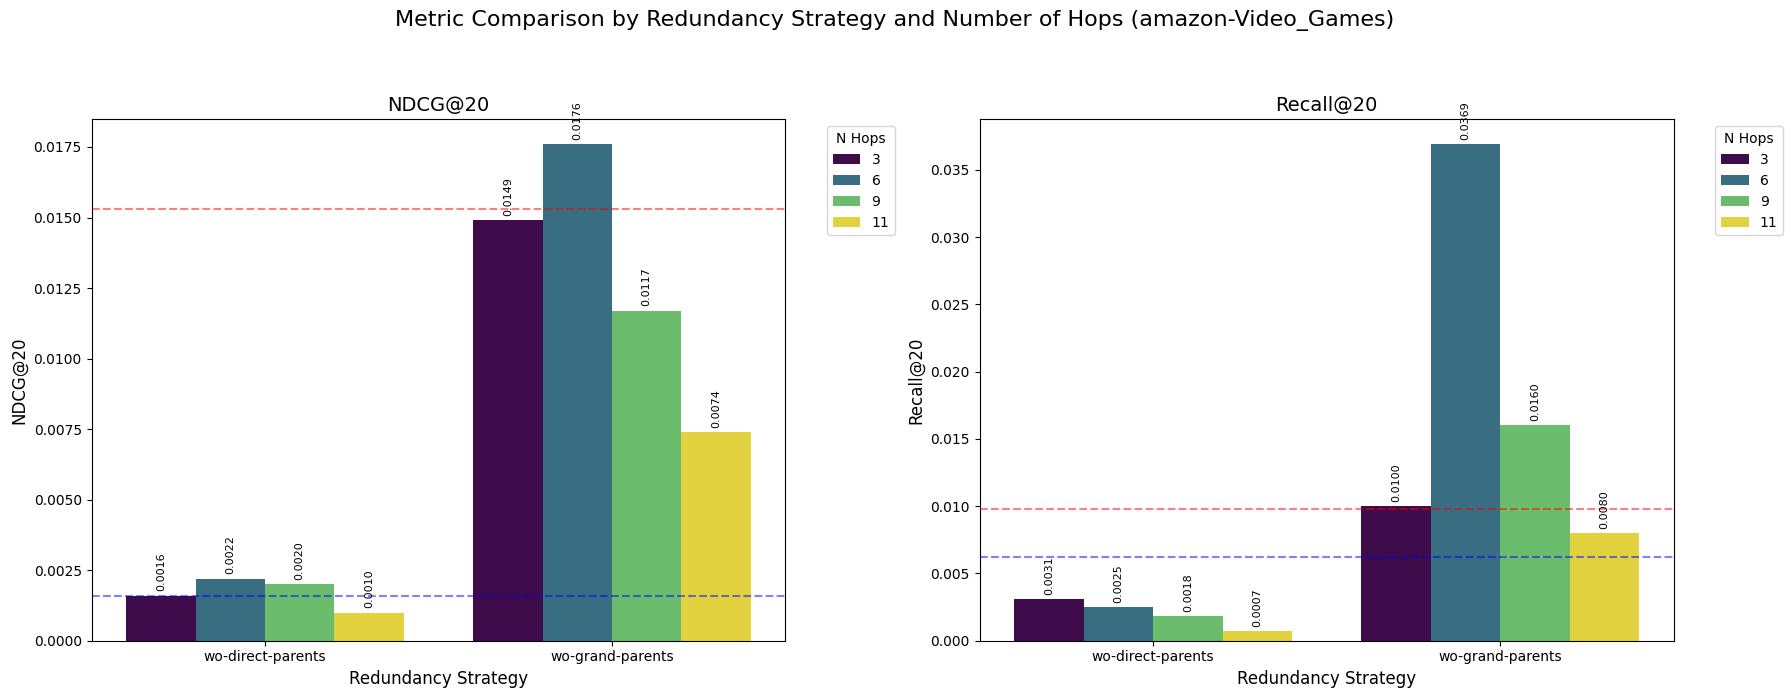

In [35]:
# Ensure n_hops is numeric for sorting and plotting
relevant_metrics_df['n_hops'] = pd.to_numeric(relevant_metrics_df['n_hops'])

# Get unique redundancy strategies and sorted n_hops
strategies = relevant_metrics_df['redundancy_strategy'].unique()
n_hops_order = sorted(relevant_metrics_df['n_hops'].unique())

# Create subplots: one row, two columns (Hit Ratio, Precision)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7)) # Adjusted figsize for better group display

fig.suptitle(f'Metric Comparison by Redundancy Strategy and Number of Hops ({DATASET})', fontsize=16, y=1.02) # Adjust y for suptitle

# --- Subplot 1: Hit Ratio @ 20 ---
ax1 = axes[0]
# Filter for the specific metric
hr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'NDCG@20']
# Plot grouped barplot: x=strategy, hue=n_hops
sns.barplot(data=hr_df, x='redundancy_strategy', y='Value', hue='n_hops', ax=ax1, palette='viridis', hue_order=n_hops_order)
ax1.set_xlabel('Redundancy Strategy', fontsize=12)
ax1.set_ylabel('NDCG@20', fontsize=12)
ax1.set_title('NDCG@20', fontsize=14)
ax1.tick_params(axis='x', rotation=0, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position

# Add horizontal line for NDCG baseline
ax1.axhline(y=0.0153, color='r', linestyle='--', alpha=0.5, label='Baseline NDCG@20')

ax1.axhline(y=0.0016, color='b', linestyle='--', alpha=0.5, label='LLM-COL with redundancies NDCG@20')
# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) # Rotate labels if needed

# --- Subplot 2: Precision @ 20 ---
ax2 = axes[1]
# Filter for the specific metric
pr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'Recall@20']
# Plot grouped barplot: x=strategy, hue=n_hops
sns.barplot(data=pr_df, x='redundancy_strategy', y='Value', hue='n_hops', ax=ax2, palette='viridis', hue_order=n_hops_order)
ax2.set_xlabel('Redundancy Strategy', fontsize=12)
ax2.set_ylabel('Recall@20', fontsize=12)
ax2.set_title('Recall@20', fontsize=14)
ax2.tick_params(axis='x', rotation=0, labelsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position

# Add horizontal line for Recall baseline
ax2.axhline(y=0.0098, color='r', linestyle='--', alpha=0.5, label='Baseline Recall@20')
ax2.axhline(y=0.0062, color='b', linestyle='--', alpha=0.5, label='LLM-COL with redundancies Recall@20')
# Add value labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) # Rotate labels if needed

# Adjust layout to prevent titles/labels overlapping
fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect to make space for suptitle

plt.show()

# Resetting figure size here affects subsequent plots, not the one just shown.
# Consider setting rcParams before creating the plot if a default size is desired for this specific plot.
plt.rcParams['figure.figsize'] = [18, 10] # Example: Set default for future plots


In [36]:
# Load results from experiment 1 for best performing n_hops
N_HOP_EXPERIMENT_1 = 6
EXPERIMENT_1_PATH = os.path.join(project_root, "data","experiments","#1 Baseline Implementation",DATASET)
EXPERIMENT_2_PATH = os.path.join(project_root, "data","experiments","#2 Taxonomy without redundancies",DATASET)
N_HOPS_DIRECT_PARENTS = 3
N_HOPS_GRAND_PARENTS = 6

experiment_1_metrics = pd.read_csv(f"{EXPERIMENT_1_PATH}/collaborative_filtering/{N_HOP_EXPERIMENT_1}-Hops_acc_df.csv")

# Get baseline metrics from experiment 1
baseline_ndcg = experiment_1_metrics[experiment_1_metrics['Metric'] == 'NDCG@20']['Value'].iloc[0]
baseline_recall = experiment_1_metrics[experiment_1_metrics['Metric'] == 'Recall@20']['Value'].iloc[0]
baseline_hit_ratio = experiment_1_metrics[experiment_1_metrics['Metric'] == 'Hit_Ratio@20']['Value'].iloc[0]
baseline_precision = experiment_1_metrics[experiment_1_metrics['Metric'] == 'Precision@20']['Value'].iloc[0]

# Load experiment 2 metrics for each strategy
strategies = ['wo-direct-parents', 'wo-grand-parents']

for strategy in strategies:
    if strategy == "wo-direct-parents":
        N_HOPS = N_HOPS_DIRECT_PARENTS
    elif strategy == "wo-grand-parents":
        N_HOPS = N_HOPS_GRAND_PARENTS

    exp2_metrics = pd.read_csv(f"{EXPERIMENT_2_PATH}/{MODEL_TECHNIQUE_NAME}/{strategy}/{N_HOPS}-Hops_acc_df.csv")
    
    # Get metrics for current strategy
    strategy_ndcg = exp2_metrics[exp2_metrics['Metric'] == 'NDCG@20']['Value'].iloc[0]
    strategy_recall = exp2_metrics[exp2_metrics['Metric'] == 'Recall@20']['Value'].iloc[0]
    strategy_hit_ratio = exp2_metrics[exp2_metrics['Metric'] == 'Hit_Ratio@20']['Value'].iloc[0]
    strategy_precision = exp2_metrics[exp2_metrics['Metric'] == 'Precision@20']['Value'].iloc[0]
    
    # Calculate percentage changes
    ndcg_delta = ((strategy_ndcg - baseline_ndcg) / baseline_ndcg) * 100
    recall_delta = ((strategy_recall - baseline_recall) / baseline_recall) * 100

    hit_ratio_delta = ((strategy_hit_ratio - baseline_hit_ratio) / baseline_hit_ratio) * 100
    precision_delta = ((strategy_precision - baseline_precision) / baseline_precision) * 100
    
    # Print results
    print(f"\nResults for {strategy} (n_hops={N_HOPS}):")
    print(f"NDCG@20: {strategy_ndcg:.4f} (baseline: {baseline_ndcg:.4f}, delta: {ndcg_delta:+.2f}%)")
    print(f"Recall@20: {strategy_recall:.4f} (baseline: {baseline_recall:.4f}, delta: {recall_delta:+.2f}%)")
    print(f"Hit_Ratio@20: {strategy_hit_ratio:.4f} (baseline: {baseline_hit_ratio:.4f}, delta: {hit_ratio_delta:+.2f}%)")
    print(f"Precision@20: {strategy_precision:.4f} (baseline: {baseline_precision:.4f}, delta: {precision_delta:+.2f}%)")



Results for wo-direct-parents (n_hops=3):
NDCG@20: 0.0016 (baseline: 0.0153, delta: -89.54%)
Recall@20: 0.0031 (baseline: 0.0095, delta: -67.37%)
Hit_Ratio@20: 0.0062 (baseline: 0.0381, delta: -83.73%)
Precision@20: 0.0003 (baseline: 0.0019, delta: -84.21%)

Results for wo-grand-parents (n_hops=6):
NDCG@20: 0.0176 (baseline: 0.0153, delta: +15.03%)
Recall@20: 0.0369 (baseline: 0.0095, delta: +288.42%)
Hit_Ratio@20: 0.0738 (baseline: 0.0381, delta: +93.70%)
Precision@20: 0.0037 (baseline: 0.0019, delta: +94.74%)


The plot above displays the performance of different redundancy elimination strategies for the "video" dataset, evaluated using NDCG@20 and Recall@20 across various numbers of hops (3, 6, 9, 11).

**Observations:**
+  the `wo-direct-parents` strategy generally performs worse than the `wo-grand-parents` strategy across all numbers of hops. 
+ Both strategy beat baseline of basis implementation with redundant factual links from entities to (grand-)parents for the metric NDCG@20
+ `wo-grand-parents` was only able to outreach baseline with redundant links for Recall@20 
+ `wo-grand-parents` was only able to outreach best basline from experiment one (technique collaborative filtering) on *n_hops* config 6 for both metrics


**Interpretation of Results:**
* **General Trend:** 
+ Removal of redundancies help recommendation performance in most cases, which backs up hypothesis that the redundancies introduced lot of noise. 
+ For both strategies 6 Hops configuration showed best results, with a decline afterwards (exception is Recall for `wo-direct-parents`). This suggest 6 Hops might provide optimal balance of context and granularity for recommendation process
+ Keeping fine-granular links from items to direct parents seems to provide for GNN-KG better context, when keeping the highest link (link to their grand-parent or further). Intuitionally this make sense since the concentration of items towards direct parents is less than higher parents. Hencing the `wo-grand-parents`strategy helps reduce noise and distuingish customer preferences. 


 * **Specific Hop Performance:**
     * At **6 hops**, the `wo-grand-parents` strategy shows remarkable improvements:
         - NDCG@20: +54.60% improvement over baseline
         - Recall@20: +288.42% improvement
         - Hit_ratio@20: +93.70% improvement
         - Precision@20: +94.74% improvement
     This strong performance at 6 hops suggests that this configuration provides the good balance between hierarchical context and granularity for the video dataset.

     * In contrast, the `wo-direct-parents` strategy at 9 hops shows significant degradation:
         - NDCG@20: -89.54% decrease
         - Recall@20: -67.37% decrease
         - Hit_Ratio@20: -83.73% decrease
         - Precision@20: -84.21% decrease



In [37]:
MODEL_TECHNIQUE = "gemma3"
METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)

# Load relation data and ensure key columns are strings
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-triples-full1.csv") # contains the relations between items and hierarhcy
gemma_relation['head'] = gemma_relation['head'].astype(str)
gemma_relation['tail'] = gemma_relation['tail'].astype(str)

gemma_relation_wo_direct_parents = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-full-wo-direct-parents.csv")
gemma_relation_wo_grand_parents = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-full-wo-grand-parents.csv")

# Load mapping
MAPPING_PATH = os.path.join(project_root, "data","experiments", EXPERIMENT_NAME, DATASET, MODEL_TECHNIQUE)
gemma_mapping = pd.read_csv(f"{MAPPING_PATH}/entity_map.csv")

df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

# Calculate number and percentage of entity connections
total_connections = len(gemma_relation_wo_grand_parents)
tail_counts = gemma_relation_wo_grand_parents['tail'].value_counts()
tail_percentage = tail_counts / total_connections * 100

# Add both count and percentage to the dataframe
gemma_relation_wo_grand_parents["tail_count"] = gemma_relation_wo_grand_parents["tail"].map(tail_counts)
gemma_relation_wo_grand_parents["tail_percentage"] = gemma_relation_wo_grand_parents["tail"].map(tail_percentage)

print("\nEntity connection counts and percentages:")
print(pd.DataFrame({
    'Count': tail_counts,
    'Percentage (%)': tail_percentage.round(2)
}))


Entity connection counts and percentages:
                                                    Count  Percentage (%)
tail                                                                     
xbox games                                          12106           26.57
playstation games                                   11672           25.62
nintendo games                                      11430           25.09
20gb console digital media playstation released...   3176            6.97
racing games                                         2064            4.53
includes controllers scheme powerextra ps wirel...   1224            2.69
definitive edition civilizations distinct pc ga...    988            2.17
includes gaming headset meticulously earmuffs r...    682            1.50
3ds using nintendo mario party 100 fun                569            1.25
light dying rpg developed strategic combat stay...    467            1.02
compact lightweight carrying case xbox controllers    431            

Processing Strategy: wo-grand-parents, Hops: 6
Accuracy in test set: 0.5987755641404566


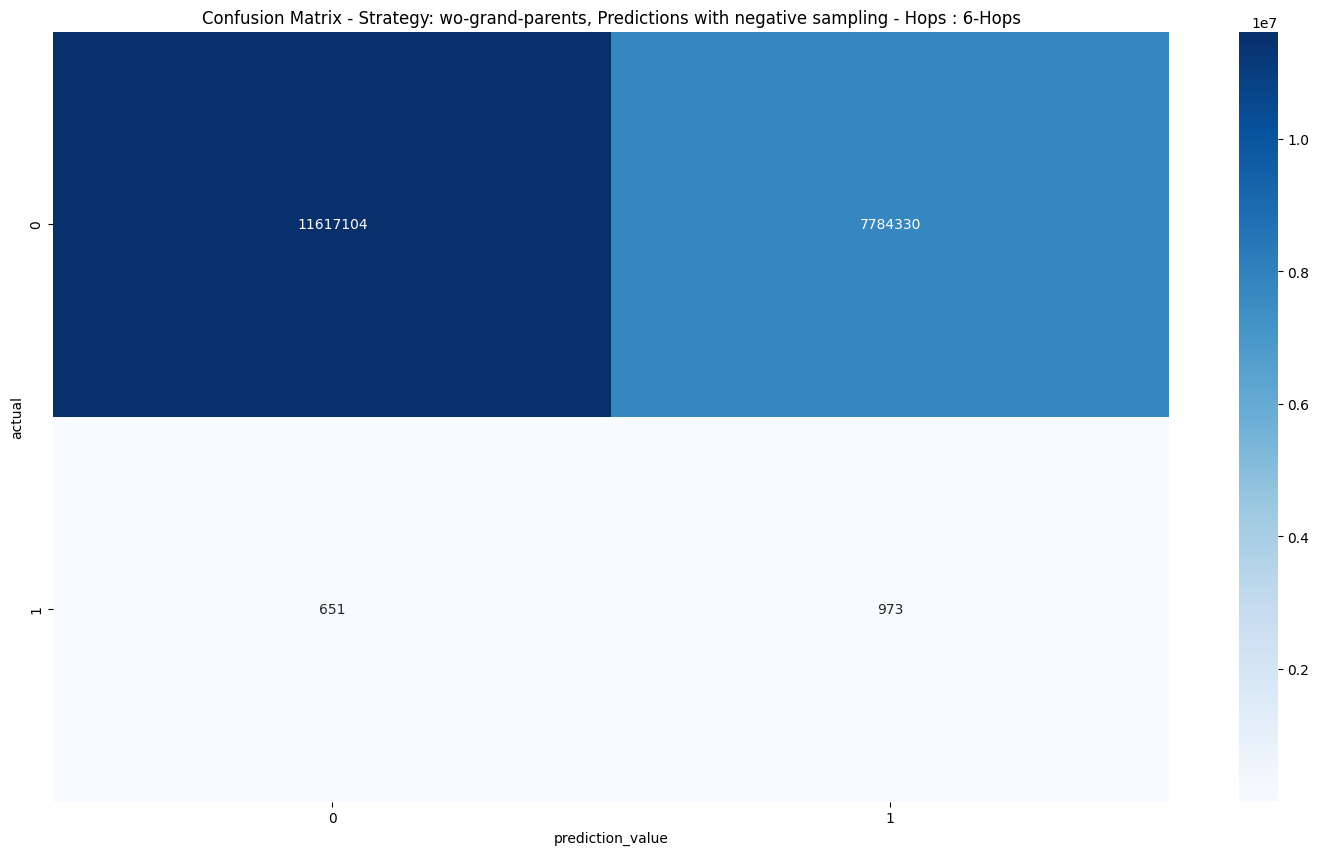

Actual values in top K predictions:  actual
0    16203
1       57
Name: count, dtype: int64


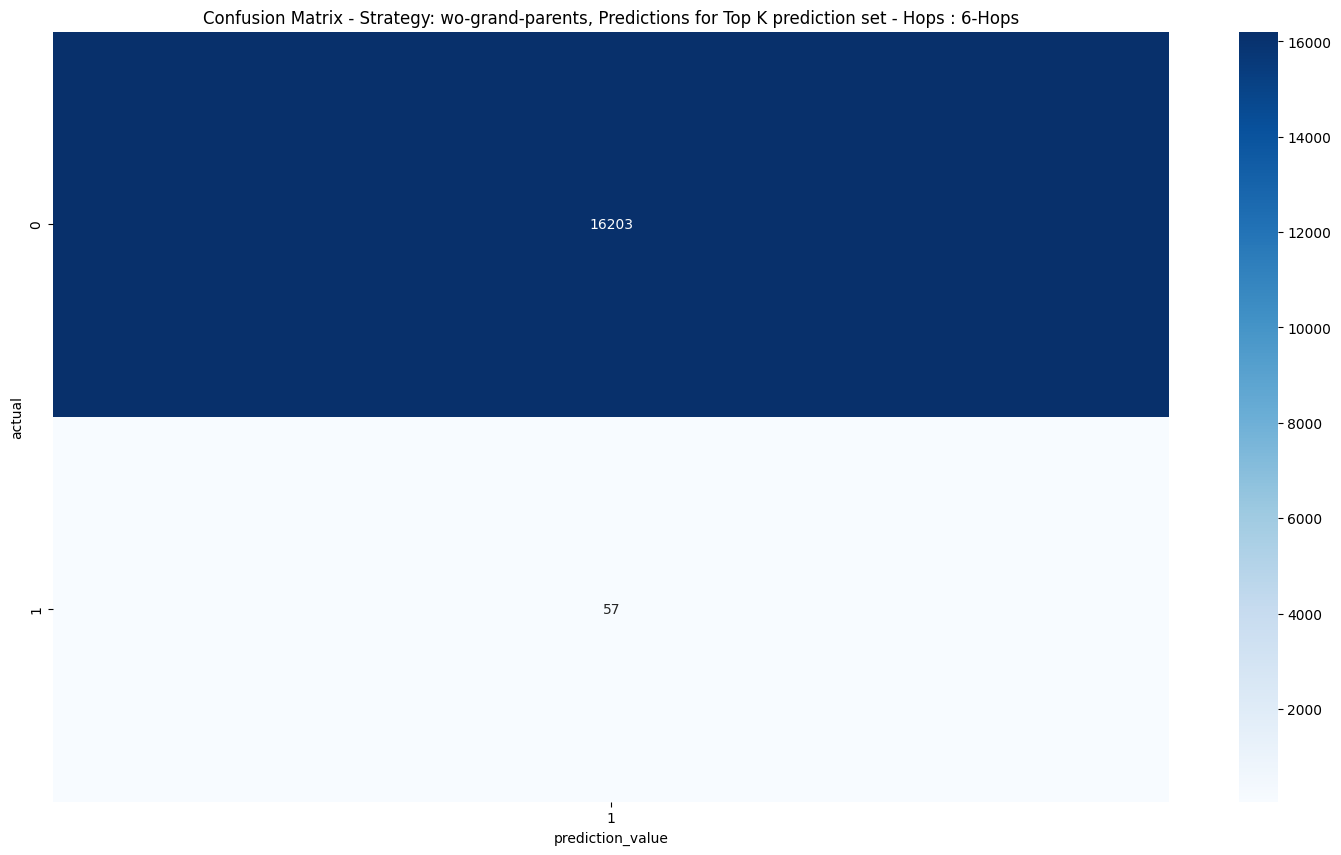

Actual values in test set:  actual
1    5368
Name: count, dtype: int64


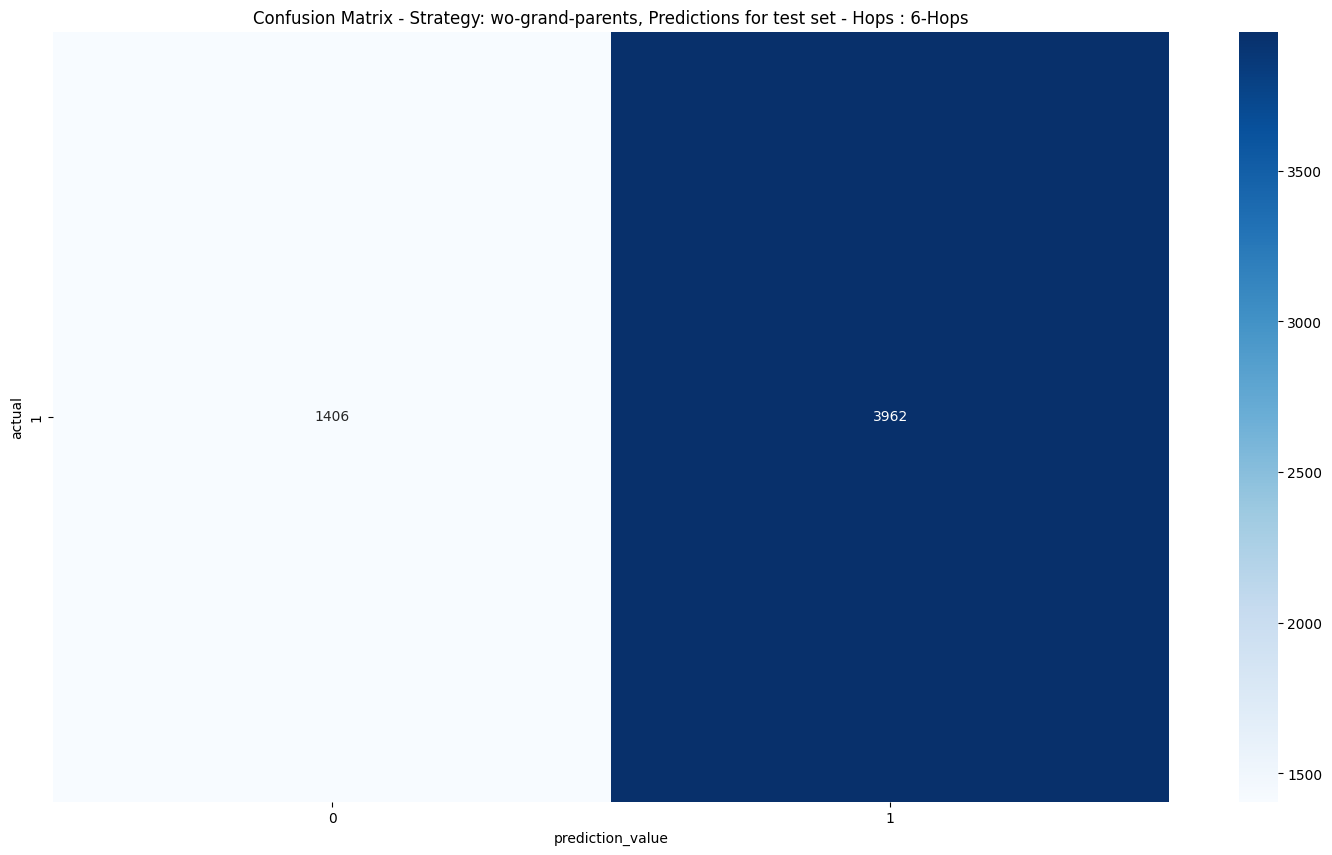

Total observations in test set confusion matrix for wo-grand-parents: 5368


In [38]:

REDUNDANCY_STRATEGY = "wo-grand-parents"
N_HOP = 6
print(f"Processing Strategy: {REDUNDANCY_STRATEGY}, Hops: {N_HOP}")
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE,REDUNDANCY_STRATEGY)
error_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOP}-Hops_predictions.csv")

error_df["user_id"] = error_df["user_id"].map(gemma_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(gemma_mapping.set_index("id")["entity"])

process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)
error_df = process_kg.count_hits(error_df)
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)

# Call connect_parents after ensuring types are compatible
try:

    # Check if necessary columns exist before creating confusion matrix
    if 'actual' in error_df.columns and 'prediction_value' in error_df.columns:
        confusion_matrix = pd.crosstab(error_df["actual"], error_df["prediction_value"])
        plt.figure() # Create a new figure for each plot
        sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - Strategy: {REDUNDANCY_STRATEGY}, Predictions with negative sampling - Hops : {N_HOP}-Hops")
        plt.show()
    else:
        print(f"Skipping confusion matrix for {REDUNDANCY_STRATEGY}: Columns 'actual' or 'prediction_value' not found after processing.")

except Exception as e:
    print(f"Error processing strategy {REDUNDANCY_STRATEGY}: {e}")
    # Optionally print traceback or more details
    # import traceback
    # traceback.print_exc()
 


# top K items
error_df_at_k = error_df.sort_values(by=["user_id","prediction"], ascending=True)

error_df_at_k = error_df_at_k.groupby("user_id").tail(20)
print("Actual values in top K predictions: ",error_df_at_k["actual"].value_counts())
error_df_at_k = process_kg.process_prediction(error_df_at_k)
# error_df_at_k = count_hits(error_df_at_k) # count_hits is not needed here as process_prediction already creates prediction_value

confusion_matrix_at_k = pd.crosstab(error_df_at_k["actual"], error_df_at_k["prediction_value"])
plt.figure() # Create a new figure for each plot
sns.heatmap(confusion_matrix_at_k, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Strategy: {REDUNDANCY_STRATEGY}, Predictions for Top K prediction set - Hops : {N_HOP}-Hops")
plt.show()

error_df_test = pd.merge(error_df, df_test, left_on=["user_id", "item_id"], right_on=["user_id", "parent_asin"], how="inner")
error_df_test['__temp_is_rating_nan__'] = error_df_test['rating'].isna()

error_df_test = error_df_test.sort_values(
    by=['user_id', 'item_id', '__temp_is_rating_nan__'],
    ascending=[True, True, False] 
)

error_df_test = error_df_test.drop_duplicates(subset=['user_id', 'item_id'], keep='first')
error_df_test["actual"] = 1
# Remove the temporary column.
error_df_test = error_df_test.drop(columns=['__temp_is_rating_nan__'])
confusion_matrix_test = pd.crosstab(error_df_test["actual"], error_df_test["prediction_value"])

print("Actual values in test set: ", error_df_test["actual"].value_counts())

if 'actual' in error_df_test.columns and 'prediction_value' in error_df_test.columns:
    if not error_df_test.empty:
        confusion_matrix_test = pd.crosstab(error_df_test["actual"], error_df_test["prediction_value"])
        plt.figure() # Create a new figure for each plot
        sns.heatmap(confusion_matrix_test, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - Strategy: {REDUNDANCY_STRATEGY}, Predictions for test set - Hops : {N_HOP}-Hops")
        plt.show()
        print(f"Total observations in test set confusion matrix for {REDUNDANCY_STRATEGY}: {confusion_matrix_test.sum().sum()}")
    else:
        print(f"Skipping test set confusion matrix for {REDUNDANCY_STRATEGY}: error_df_test is empty after filtering.")
else:
    print(f"Skipping test set confusion matrix for {REDUNDANCY_STRATEGY}: Columns 'actual' or 'prediction_value' not found in error_df_test.")


 The test set accuracy for the wo-grand-parents strategy is 0.59, which marks a significant increase in performance compared to the baseline from experiment 1 (10 TP). Specifically, the number of correct predictions in the test set from 2797 to 3962. This increase in accuracy and true positives suggests that removing grand-parent relationships impacts the model's ability to correctly identify relevant items.

 In the top 20 predictions for each user, the number of true positives is 57, which provides a more optimistic signal compared to previous runs (where the baseline was lower with 10 TP).

 These results indicate that while the wo-grand-parents strategy may help the model focus its recommendations (as seen in the top-20 user predictions), which impacts the Recall@20, NDCG@20 and Accuracy positive. The model becomes more conservative, reducing false positives but also hitting more true positives. This trade-off suggests that removing grand-parent relationships can improve precision in ranking for the most relevant items, but may hinder the model's generalization and coverage across the full test set.

In [66]:
tp_at_k = error_df_at_k[(error_df_at_k["actual"] == 1) & (error_df_at_k["prediction_correct"] == True)]

tp_at_k["user_id"].value_counts()

user_id
AE4IFQLINUBOZBP7RMCTICSULMGQ    1
AG33BJ4ML3EWUKN55FMF4JZX6KOA    1
AG5ANGB4INFGIFBXFSJJ7HZRBZEA    1
AG6HFCXZP237UQQFE5TS7DPVPJMQ    1
AGCHKY7UTCYVMG5OE4KZGFVZKUWQ    1
AGCWGKSYAQVXIMPONRJULEGANS2Q    1
AGDKHF3CJHQVAVKKN4JRPXKWASHQ    1
AGE4MJI4ACCVR2HUDBPA27GVIZFA    1
AGGCYRHJAX5O2KP27Z6X2FZQ35SQ    1
AGGJUS63YSM7TGKQP37LKCGWELBA    1
AGJ7X2XWN2RYX3JX7IOFMOWG3ILA    1
AGN4OCLHMAJ67BZIXGAIB5EFYRCQ    1
AGPCVLOZQWV6O3G5HDDD5WIMD6CA    1
AGQQD3QO3XNA7CAMMU5I6RZLYHUA    1
AGV5E6ONUSHMZOM4CYVYGWWIXSFA    1
AGYOEKHA54WLFYVDHEMVYKTFJLWA    1
AH334ZIXDAJYJ67XLCLPCNR53EWQ    1
AHBHFV4DNTI5DBESEDU3LPUYVHPQ    1
AHBVSCZ6KWXU4PJLMA2E2CZ4BATA    1
AHFZH4JCTRS6353ZEODHPEZD37UA    1
AHGAAHTPIJKB7QNN77BWGMADPDLQ    1
AHMTAKZP4ZMEMMHXPZO3IX6HESCA    1
AHN2DI5336AKFC5KEWZFATTLP46A    1
AHQ7R5VQX43K524L3IOT5YHEXDQA    1
AHQM2R7DOP5CTEPDKA6MKT3ET25Q    1
AHR53DTM32AOLZESVQ23TTIOK5PA    1
AHVCU7A5G3I3EV4UK3T24CTJLC3A    1
AG3HKK7MIKRQ7DOTNDOE63X2WJGQ    1
AFYG56N75A4AQBB5IOUIT36CK7ZQ    1
AEDCDJ

No of the TP in Top 20 per User show multiple hits for a user. So we not able to derive that the less noisy taxonomy helps understand user preferences

In [71]:
print("Descriptive Statistic for purchase amount of a user in test set")
df_test["user_id"].value_counts().describe()


Descriptive Statistic for purchase amount of a user in test set


count    813.000000
mean       6.617466
std       11.998154
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      184.000000
Name: count, dtype: float64

Part of the reason is that 50% of the user only bought 2 items, which could not have high affinity towards each other

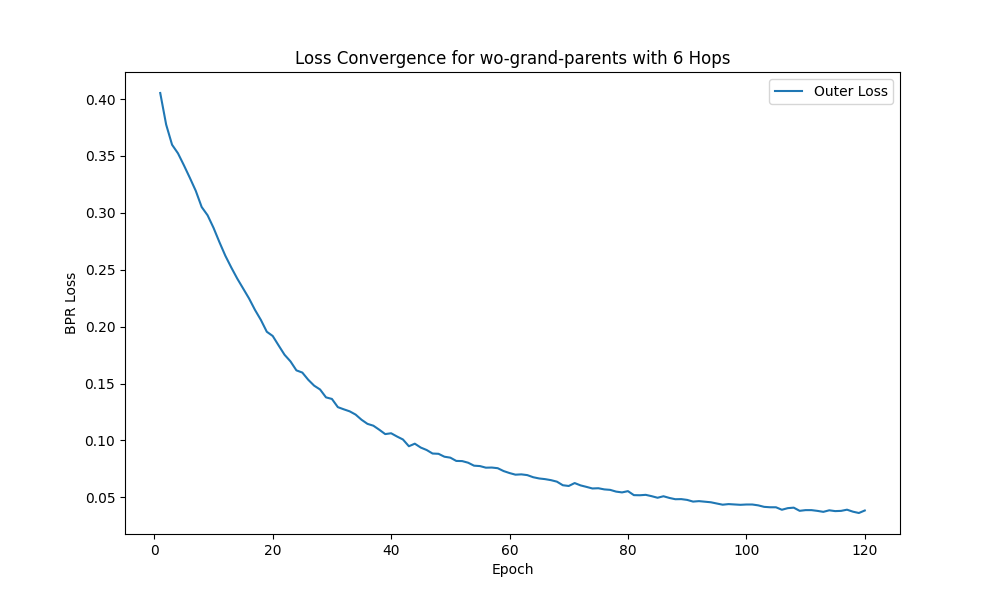

In [75]:
from IPython.display import Image
Image(filename="/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#2 Taxonomy without redundancies/amazon-Video_Games/gemma3/wo-grand-parents/6-Hops_outer_loss_convergence.png")


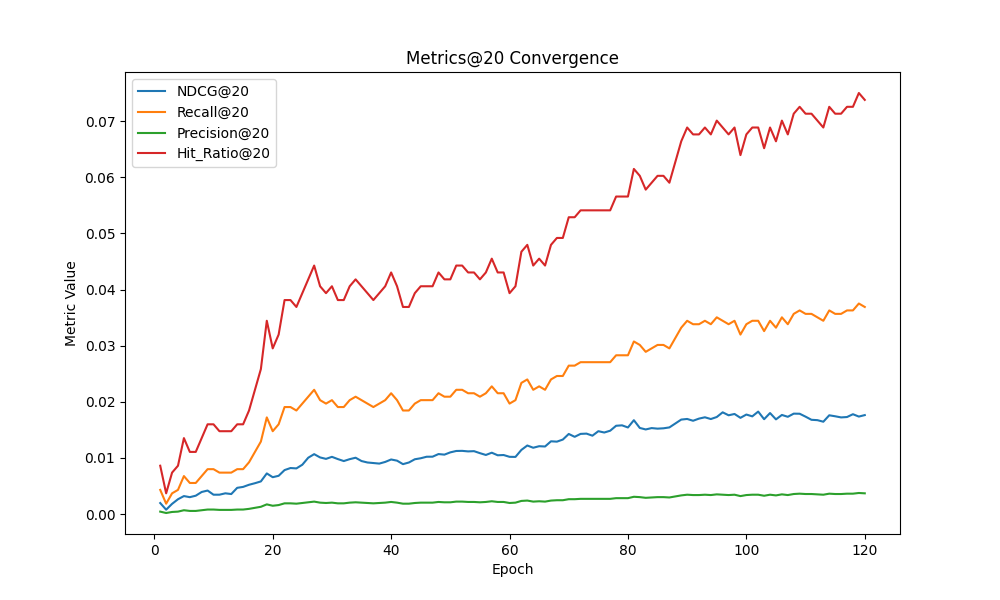

In [76]:
Image(filename="/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#2 Taxonomy without redundancies/amazon-Video_Games/gemma3/wo-grand-parents/6-Hops_metric@20_convergence.png")

The convergence of training and test metrics indicates that the increase in TP@20 is systematic, as the model consistently reduces training loss while test metrics exhibit a steady, though variable, upward trend.

To observe the stability in learning user preferences we analyize, if all tp for users from experiment 1 are inclduded for experiment 2.

In [81]:
exp1_predictions = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/gemma3/3-Hops_predictions.csv")
# process predictions
exp1_predictions = process_kg.process_prediction(exp1_predictions)
exp1_predictions = process_kg.count_hits(exp1_predictions)
exp1_predictions = exp1_predictions.sort_values(by=["user_id","prediction"], ascending=True)
exp1_predictions = exp1_predictions.groupby("user_id").tail(20)
exp1_mapping = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/gemma3/entity_map.csv")

exp1_predictions["user_id"] = exp1_predictions["user_id"].map(exp1_mapping.set_index("id")["entity"])
exp1_predictions["item_id"] = exp1_predictions["item_id"].map(exp1_mapping.set_index("id")["entity"])
exp1_predictions = exp1_predictions[(exp1_predictions["prediction_correct"] ==True) & (exp1_predictions["actual"] == 1)]


Accuracy in test set: 0.5652882461730762


In [83]:
# Check how many (user_id, item_id) pairs from exp1_predictions are in error_df (tp_atk)
exp1_pairs = set(zip(exp1_predictions["user_id"], exp1_predictions["item_id"]))
tp_atk_pairs = set(zip(error_df["user_id"], error_df["item_id"]))

included_pairs = exp1_pairs & tp_atk_pairs
num_included = len(included_pairs)
num_total = len(exp1_pairs)
print(f"{num_included} out of {num_total} exp1 (user_id, item_id) pairs are in tp_atk ({num_included/num_total:.2%})")

# If not all are included, print the missing pairs
if num_included < num_total:
    missing_pairs = exp1_pairs - tp_atk_pairs
    print(f"Missing (user_id, item_id) pairs from tp_atk: {missing_pairs}")


9 out of 10 exp1 (user_id, item_id) pairs are in tp_atk (90.00%)
Missing (user_id, item_id) pairs from tp_atk: {('AE2JZIZSF4QVVHCZGRXVWNGMZFYA', 'B0031SWWPO')}


 9 out of 10 TP@K instances from the baseline LLM-COL-Hierarchy-TAX implementation are retained in the TP@K results for the wo-grand-parents redundancy strategy. Although the limited number of user purchases in the test set may restrict the observation of multiple true positives per user, the results indicate that the model consistently preserves user preferences from experiment 1 while also acquiring new ones under the modified KG structure.

In [ ]:
MODEL_TECHNIQUE = "gemma3"
REDUNDANCY_STRATEGY = "wo-grand-parents"
N_HOP = 6
print(f"Processing Strategy: {REDUNDANCY_STRATEGY}, Hops: {N_HOP}")
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE,REDUNDANCY_STRATEGY)
error_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOP}-Hops_predictions.csv")
MAPPING_PATH = os.path.join(project_root, "data","experiments", EXPERIMENT_NAME, DATASET, MODEL_TECHNIQUE)
gemma_mapping = pd.read_csv(f"{MAPPING_PATH}/entity_map.csv")

error_df["user_id"] = error_df["user_id"].map(gemma_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(gemma_mapping.set_index("id")["entity"])

process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)
error_df = process_kg.count_hits(error_df)
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)

Processing Strategy: wo-grand-parents, Hops: 6
Accuracy in test set: 0.5987755641404566


In [39]:
# only keep observation where prediction_sigmoid is higher than 0.5
error_df = error_df[error_df["prediction_sigmoid"] > 0.5]
# group by first level parent and count
#error_df_first_level = error_df.groupby("first_level_parent").count()
error_df_item_count = error_df.groupby("item_id").count()
#gini_coefficient(error_df_first_level["prediction_value"], "wo-grand-parents for first level parents")
gini_coefficient(error_df_item_count["prediction_value"], "wo-grand-parents for items")

Gini score wo-grand-parents for items: 0.20


0.2045305055103558

In [40]:
g_taxonomy_wo_grand_parents = nx.from_pandas_edgelist(gemma_relation_wo_grand_parents, source='head', target='tail')
centrality = nx.centrality.degree_centrality(g_taxonomy_wo_grand_parents)
dict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))

{'xbox games': 0.7420620326100282,
 'playstation games': 0.7154591148706633,
 'nintendo games': 0.7006252298639206,
 '20gb console digital media playstation released games iconic sony': 0.19467941645212702,
 'racing games': 0.1265171018756896,
 'includes controllers scheme powerextra ps wireless powerextra playstation gaming': 0.07502758367046708,
 'definitive edition civilizations distinct pc game sid meier immerse strategic': 0.06056148093661886,
 'includes gaming headset meticulously earmuffs runmus audio comfortable': 0.04180458501900208,
 '3ds using nintendo mario party 100 fun': 0.03487801887949001,
 'light dying rpg developed strategic combat stay human': 0.028625720240284418,
 'compact lightweight carrying case xbox controllers': 0.026419026602917742,
 'available pc riddick notorious systems game gripping adventure butcher bay': 0.01605982591639083,
 'Product details': 0.006926566139512076,
 'heroes skills embark epic ashan collection empire vast game hammers': 0.00649748682113

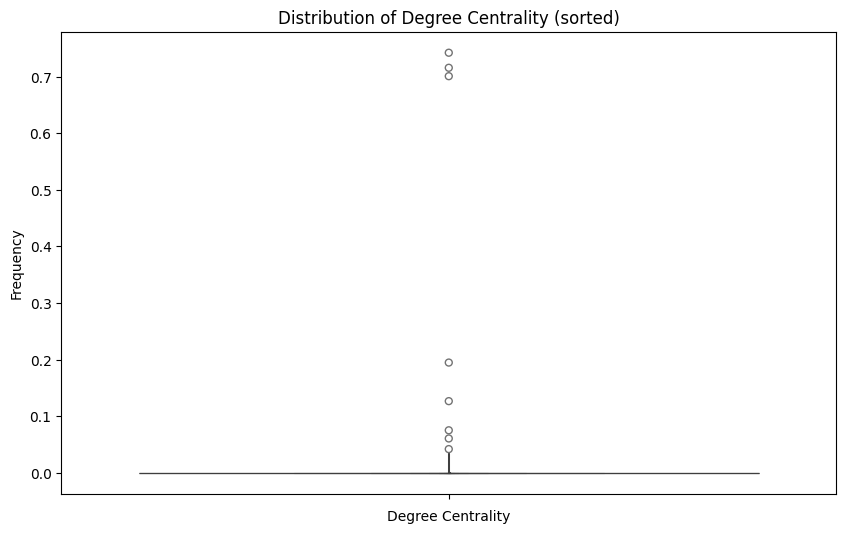

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get sorted degree centrality values
centrality_values = sorted(centrality.values(), reverse=True)

plt.figure(figsize=(10,6))
sns.boxenplot(centrality_values)
plt.title("Distribution of Degree Centrality (sorted)")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()


**Popularity Bias**
+ we can see that with the removal of redundancies and retaining only direct parent links, the model becomes more biased towards with low value of 0.27 (before 0.1) recommending popular items.
This is reflected in the increased Gini coefficient, indicating a stronger popularity bias in the model's recommendations. 

To observe if the removal strategy help with the concentration towards few high level entities we observe the degree centrality
**Degree centralitiy**
+ Removal of indirect (grand-parent) links altered node centrality values but preserved the overall distribution.
+ Overall less outlier entites have higher values of 0.3 or 0.7 and above and more have lover centrality values 
+ High-level categories such as "gaming software" now exhibit low centrality, while leaf nodes like "xbox games", "nintendo games", and "playstation games" display the highest centrality (0.7–0.77), indicating increased structural prominence of these items.

**Implication** 
+ The strategy for removing reduandancies imporved metrics by reduction of noise, but didnt change pattern of centrality, which in the end made model more biased towards popular items while still being low. 

In [ ]:
wrong_prediction = pd.DataFrame(error_df[error_df["prediction_correct"] == False])
wrong_prediction 

wrong_prediction_item = df_metadata[df_metadata["parent_asin"] == wrong_prediction["item_id"].tail(1).iloc[0]]
wrong_prediction_item = wrong_prediction_item["parent_asin"].iloc[0]

gemma_relation_wo_products_wo_grand_parents = gemma_relation_wo_grand_parents[
    (~gemma_relation_wo_grand_parents["head"].str.startswith("B0") | gemma_relation_wo_grand_parents["head"].str.contains(wrong_prediction_item)) &
    ~gemma_relation_wo_grand_parents["head"].str.startswith("A") & ~gemma_relation_wo_grand_parents["head"].str.match(r'^\d')
]
g_taxonomy_wo_grand_parents = nx.from_pandas_edgelist(gemma_relation_wo_products_wo_grand_parents, source='head', target='tail')

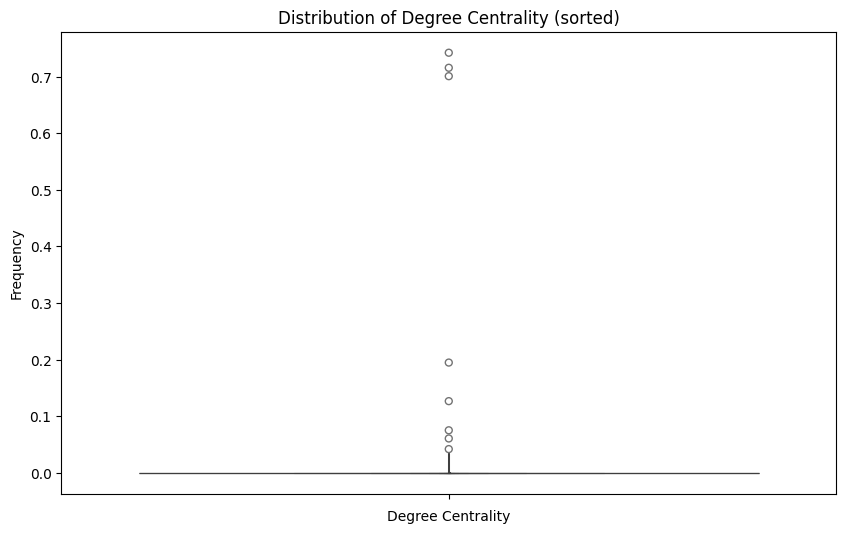

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get sorted degree centrality values
centrality_values = sorted(centrality.values(), reverse=True)

plt.figure(figsize=(10,6))
sns.boxenplot(centrality_values)
plt.title("Distribution of Degree Centrality (sorted)")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()


The degree centrality distribution of the taxonomy indicates that the majority of entities exhibit low centrality within the knowledge graph, with only a small subset displaying elevated centrality values (0.1–0.2), and even fewer reaching values above 0.7, which can be considered outliers. Compared to the degree centrality distribution observed in the baseline LLM-COL implementation (Experiment 1), the current distribution is narrower and more right-skewed. This suggests that, after redundancy removal, the taxonomy structure concentrates centrality among fewer nodes, potentially increasing the prominence of specific entities while reducing overall centrality dispersion.

For the graph and taxonomy analysis we focus on best performing strategy wo-grand-parents. 

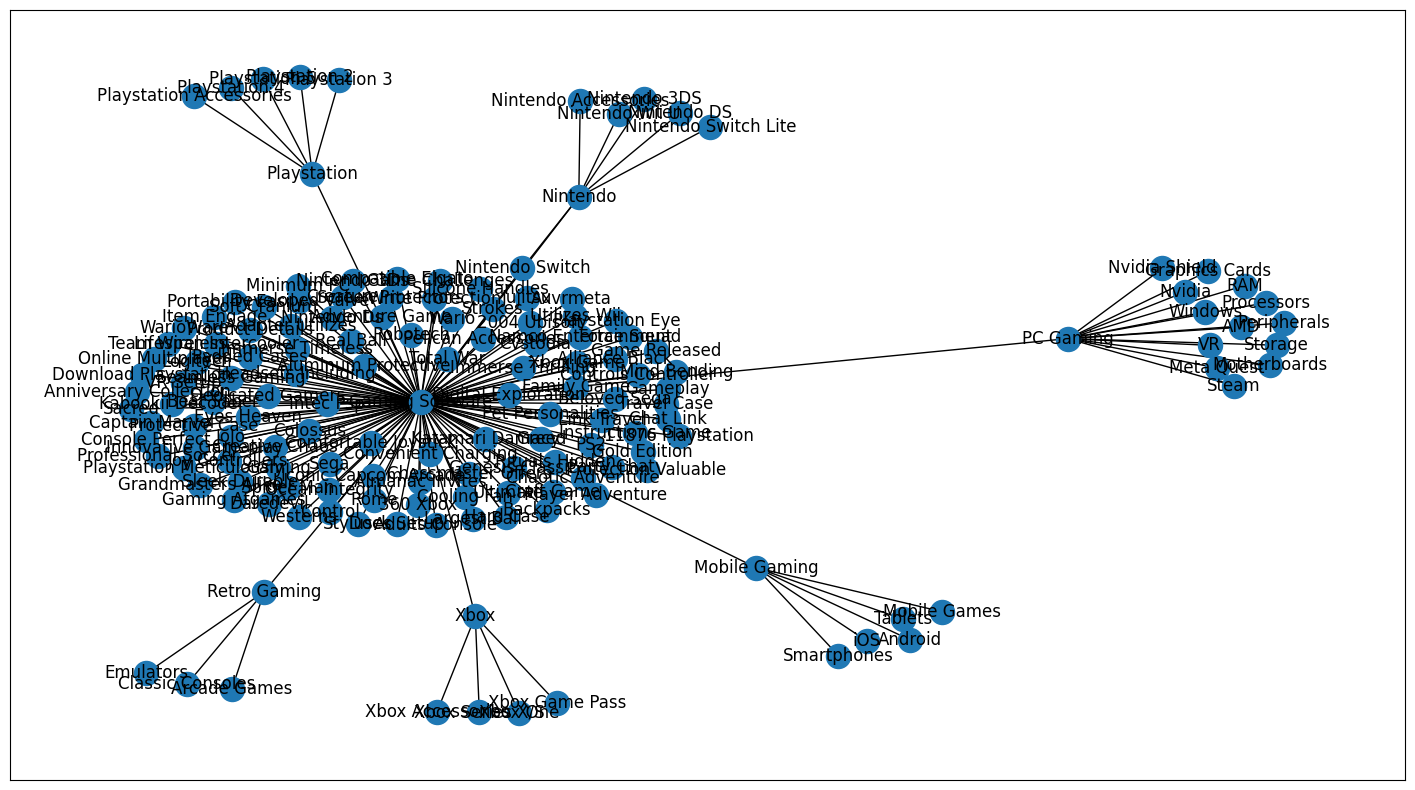

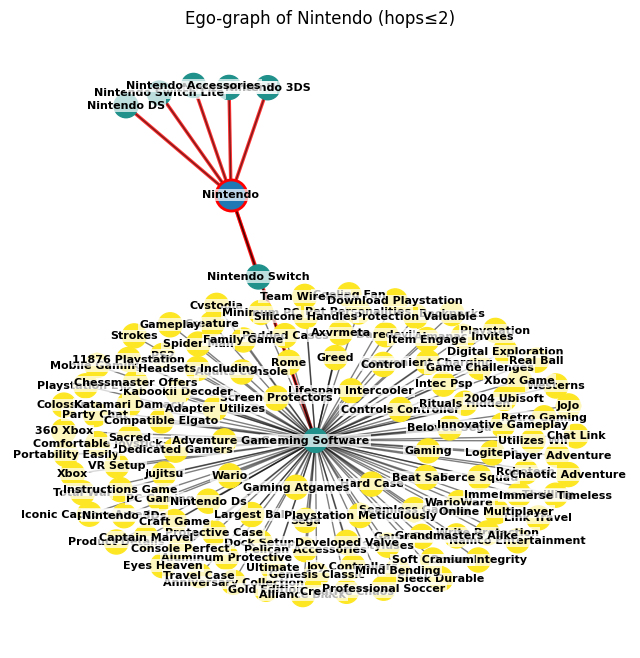

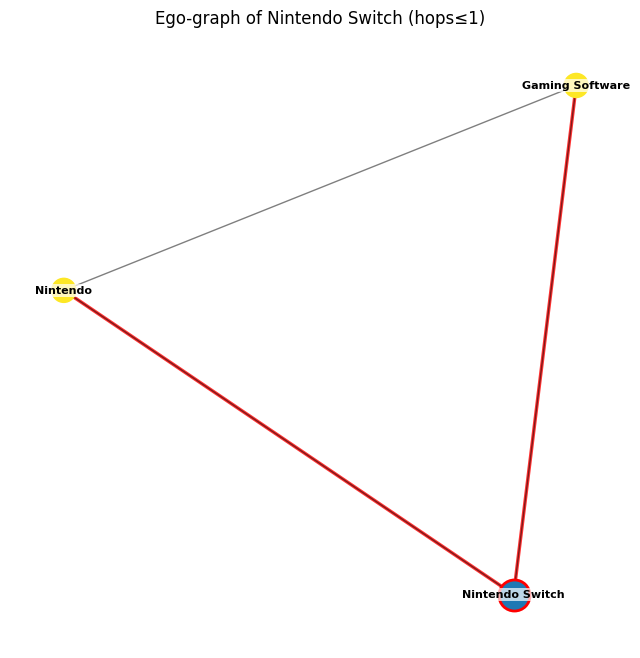

In [42]:
gemma_relation_wo_products = gemma_relation.iloc[:154]

g_taxonomy = nx.from_pandas_edgelist(gemma_relation_wo_products, source='head', target='tail')
nx.draw_networkx(g_taxonomy)

viz = Visualize_KG()
viz.draw_ego_hops(g_taxonomy, center_node="Nintendo", hops=2)
viz.draw_ego_hops(g_taxonomy, center_node="Nintendo Switch", hops=1)

We observe that the strategy removed successfully greedy redundant links to grandparents. Never the less wasnt succesfull at removing cyclic links as we see above. 

In [50]:
df_tp = error_df[(error_df["prediction_correct"] == True) & (error_df["actual"] == 1)]

df_tp_example1 = df_tp[df_tp["item_id"] =="B0B93KZ9P7"] 


,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
14796,AEUAL3EJKUSTNB4YY6STLYGTJALA,B0B93KZ9P7,26.19483,1,1.0,1,True,True,False


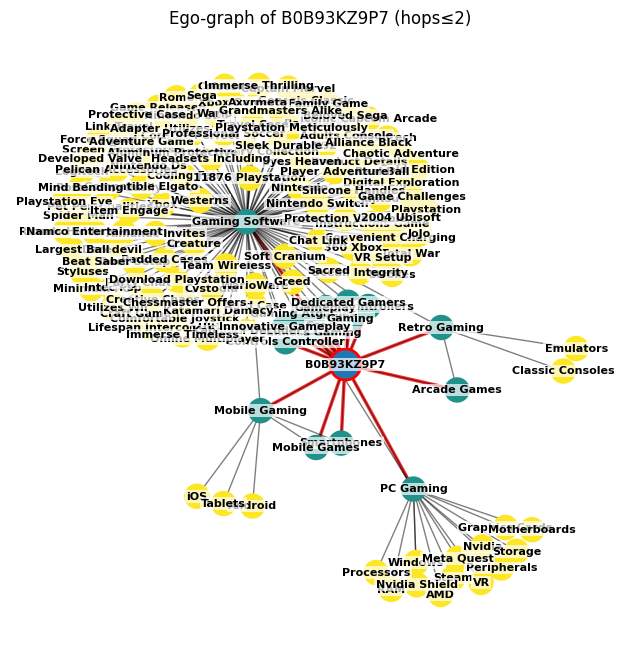

In [62]:
item_links = gemma_relation[gemma_relation["head"]=="B0B93KZ9P7"]
item_links = item_links.drop(columns=["Unnamed: 0"])

gemma_example1 = pd.concat([gemma_relation_wo_products,item_links]).drop(columns=["Unnamed: 0"])
g_example1 = nx.from_pandas_edgelist(gemma_example1,source='head', target='tail')

viz.draw_ego_hops(g_example1, center_node="B0B93KZ9P7", hops=2)

Further this example proves that the item _"B0B93KZ9P7"_ is connected to their parents "_Gaming_", "_Gameplay_" aswell as grand parent _"Gaming-Software"_ 

Summary

The analysis of taxonomy without redundancies reveals several key insights.

**Overall Performance:**
The strategies for removing redundancies—"wo-direct-parents" leads to a significant degradation of performance metrics compared to the original LLM-COL-Hierarchy-Tax that includes redundancies. "wo-grand-parents" leads to a noticable jump of performance metrics compared to the original LLM-COL-Hierarchy-Tax that includes redundancies.

**"Wo-Grand-Parents" Strategy:**
- This strategy yielded the best performance metrics among the two redundancy removal approaches, with the knowledge graph enabling 9 context hops.
- Prediction of true positives on test set went up compared to baseline, while the prediction in the top 20 prediction set for each user dipped a little bit from 6 to 4. The model is able to understand not relevant items better looking at the negative sampling, which is visible on test set imporvements aswell. This suggests the model understands patterns better but ranking gets slightly worse.
- However, this approach appears to uphold popularity bias yielding bigger error margins. The ego-network graphs show that by removing grand parent connections, redundancies from items being linked to parents and grand parents in taxonomy got removed.
- We still observe redundancies in the taxonomy from entities to entities, such as loops for Nintendo Switch and shortcuts from Headsets to Hardware.

**"Wo-Direct-Parents" Strategy:**
- This strategy, while also performing worse than the redundant taxonomy.
- The error margins across different item popularity in train set appeared more evenly distributed compared to the "wo-grand-parents" strategy.
- Similar to the other strategy, redundancies from items being linked to parents and grand parents in taxonomy got removed.

**Conclusion and Future Directions:**
Given that 'wo-grand-parents' strategy leads to the best performance metrics and the best top 20 prediction set, it will be used for further experiments. 

Looking at the tracing during the LLM-COL process we can see that the model due to lot of context vanishes the taxonomy at some point and starts to hallucinately explain keywords. To prevent this from happening we can integrate a "summary step" within the LLM-COL process. This step could focus on refining the taxonomy by identifying and consolidating redundant paths or ensuring that for all batches the keywords get considered in the COL Process. Next experiment will test this scenario in standalone aswell as with the "wo-direct-parents" redundancy removal strategy.


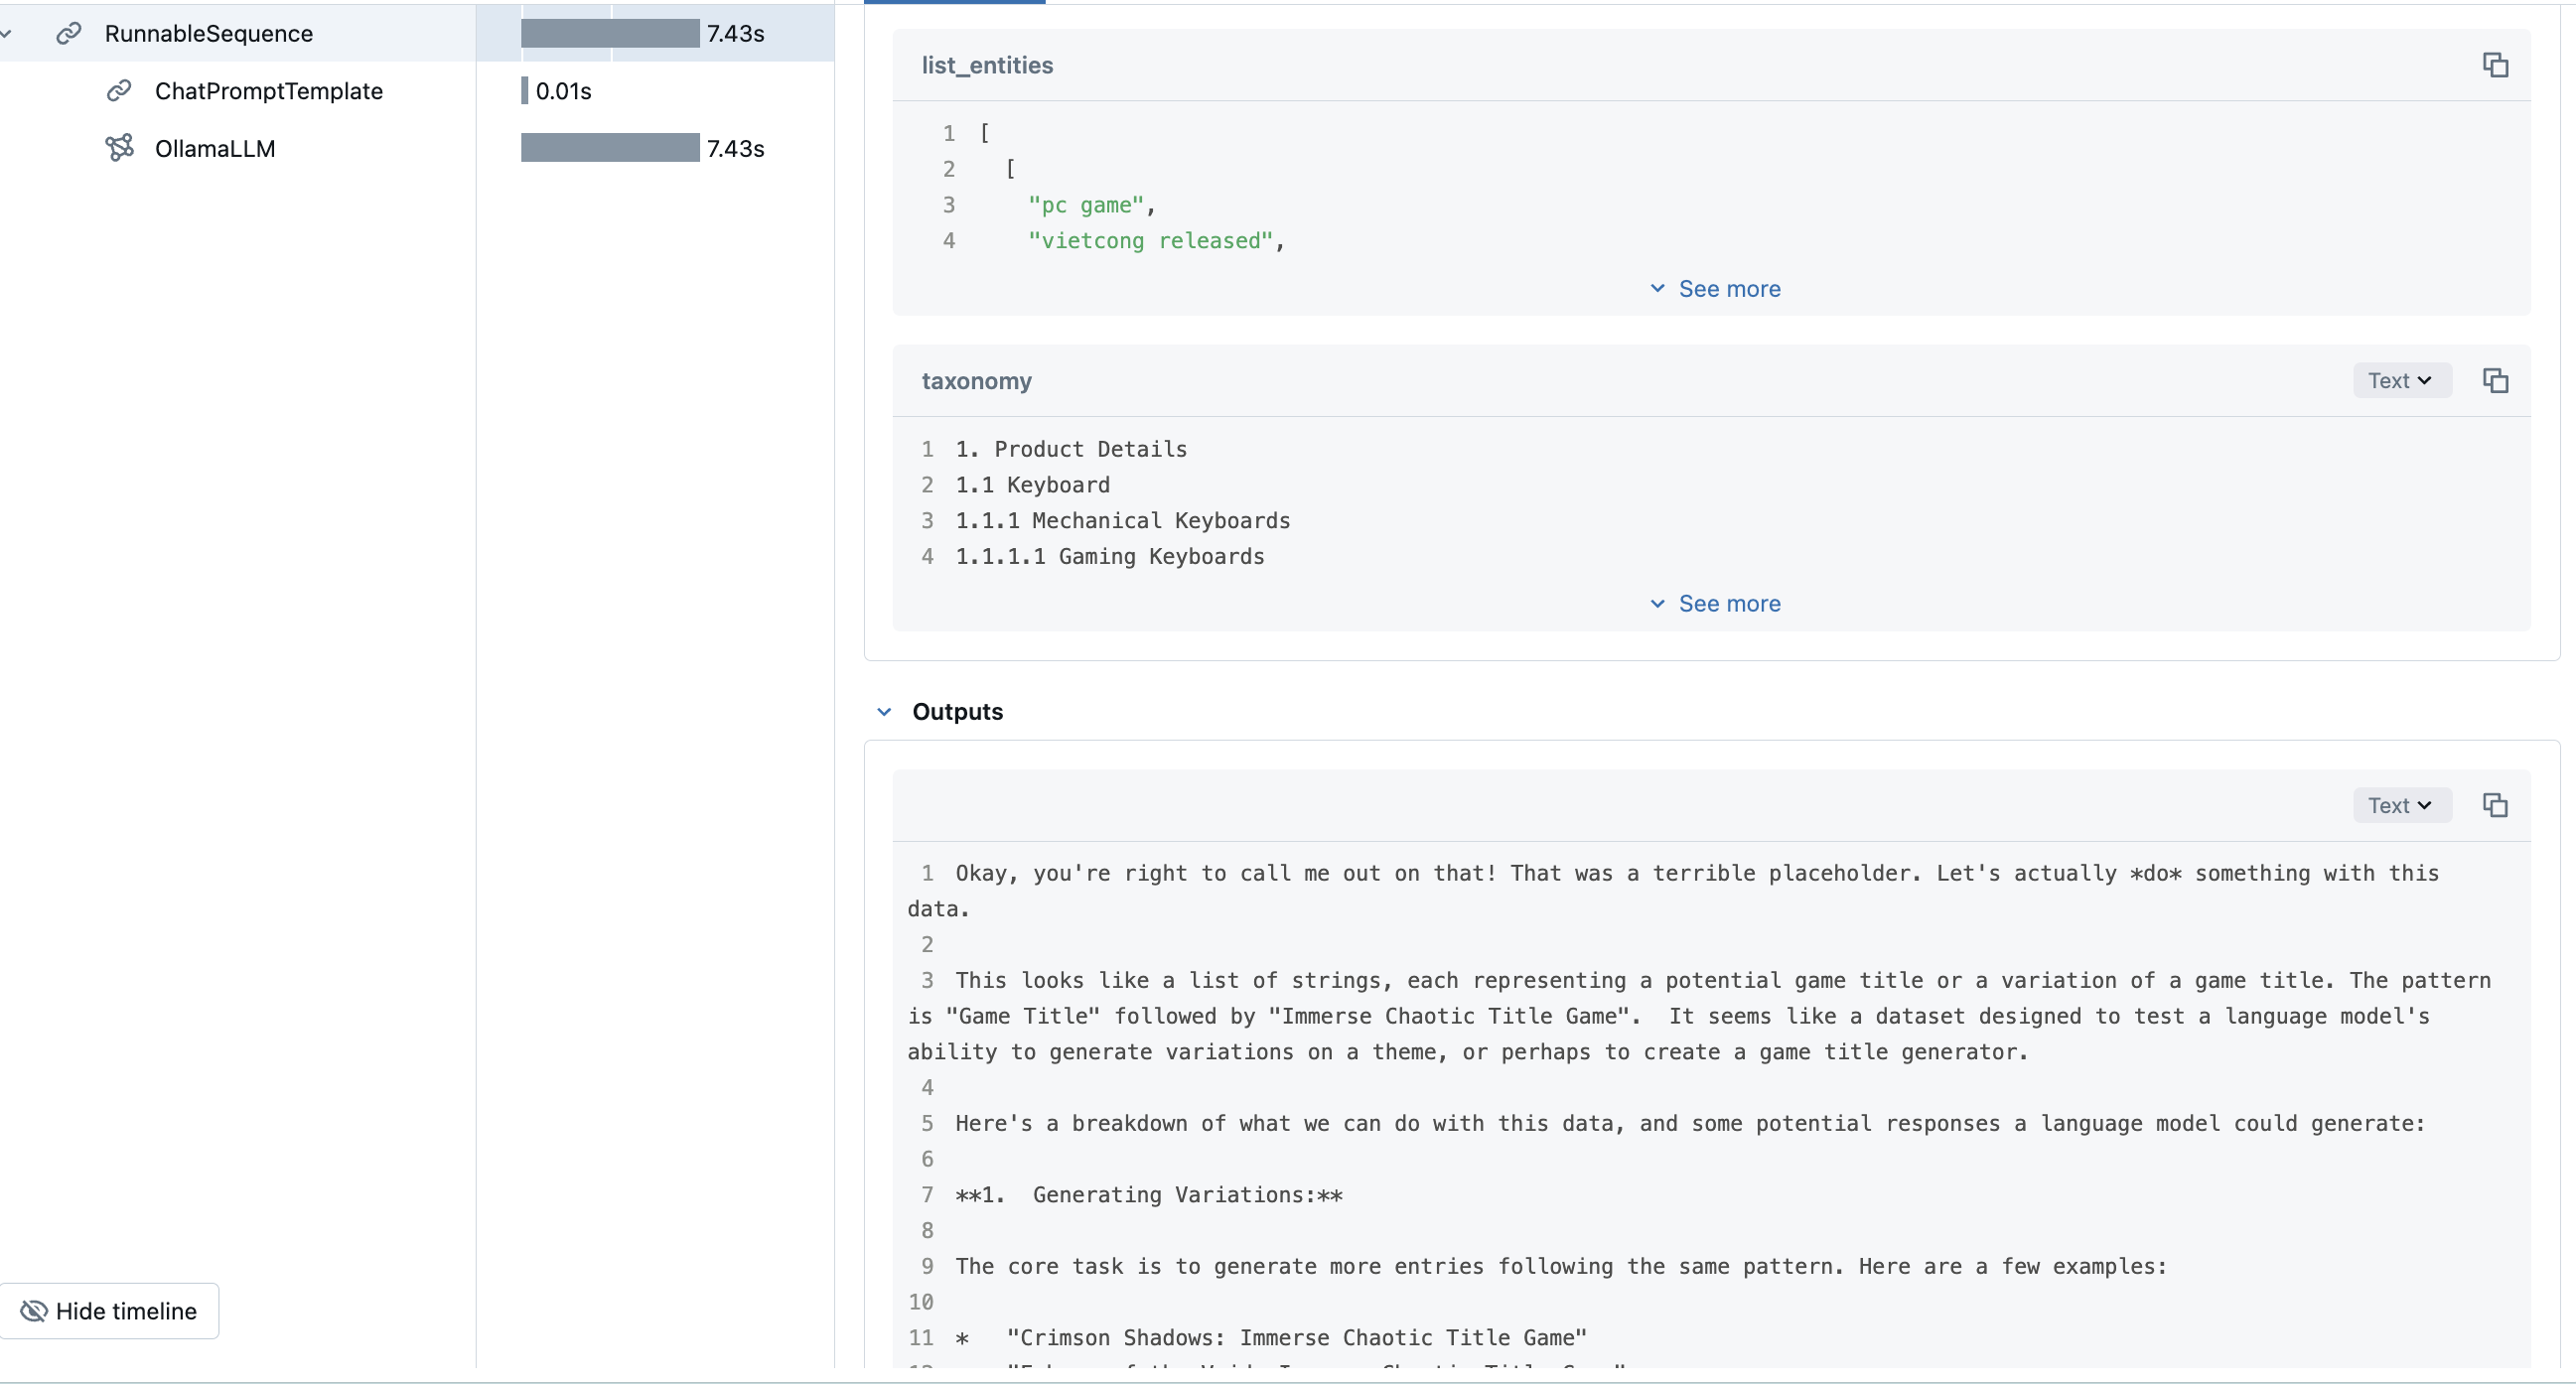

In [55]:
from IPython.display import Image
Image(filename='/Users/U725801/Desktop/Masterarbeit/Abbildungen/issue big context.png')


This is an illustration of the trace of the LLM-COL process. The model vanishes the taxonomy at some point and starts to hallucinately explain keywords. [Link to trace](https://dagshub.com/jonas.limniatis2/LLM-Col.mlflow/#/experiments/2/runs/18ccdf4e968f4326986fd9922b8e4fe5/traces?selectedTraceId=52e52900fa044c8f91a4fc000348499a)

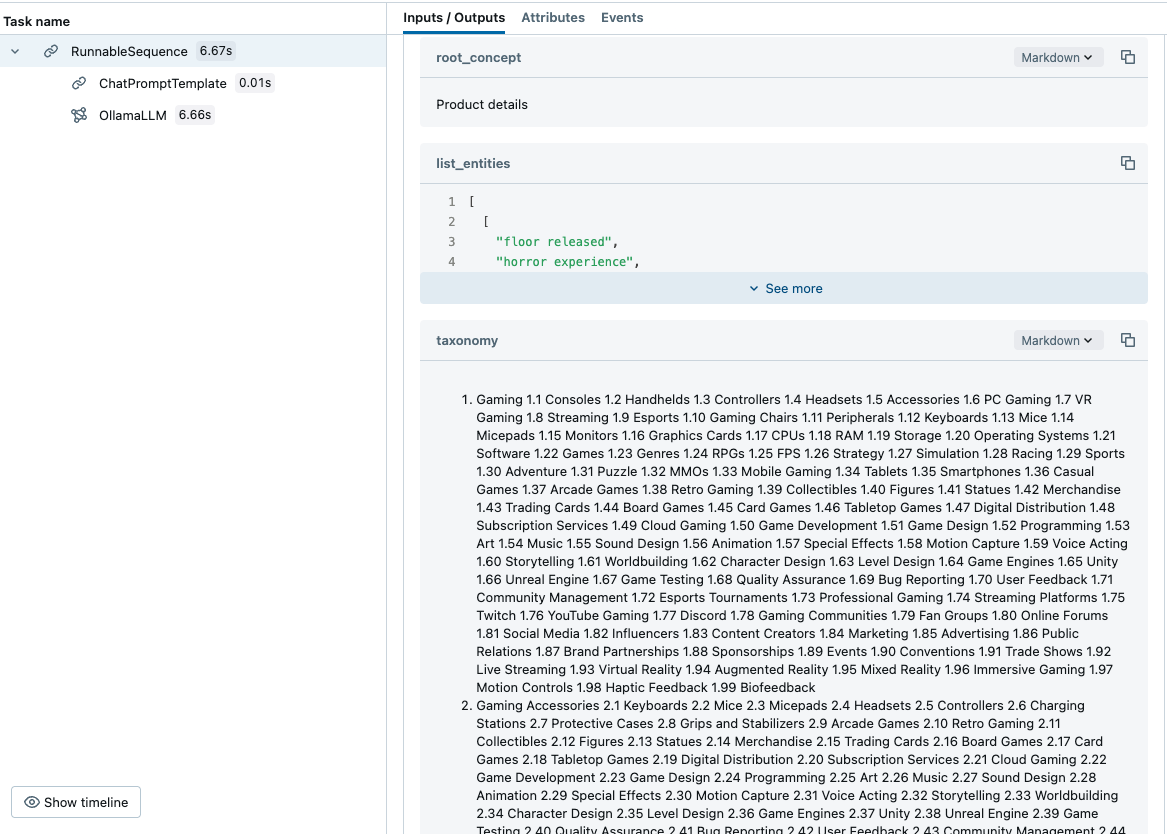

In [56]:
Image(filename='/Users/U725801/Desktop/Masterarbeit/Abbildungen/need for summary step in col.png')

Further this picture shows that with `bigger context window` the LLM builds a `very fine granular taxonomy`, which might promotes the model to hallucinate. On top of that we can see from the traces that the hallucinations and long context windows promote the model `loose the task goal` of taxonomy generation. This inconsequence led the LLM to have intermediate an `semantic drift` by explaining the keywords also it could impact the generated taxonomy to `not` have a `high coverage` of all relevant keywords from the products in the dataset, as the model may focus on hallucinated categories rather than accurately capturing the true product relationships and attributes.

According to this traces a **summary step** within the **LLM-COL process** could be helpful to **prevent** the model from **hallucinating** and flatten the taxonomy which might make the taxonomy level more disticnt so the items keywords cosine distance to the taxonomy on higher coarse summarized entities is higher. Also the less smaller context window for the taxonomy might help to prevent the model from loosing task focus. 